### Tool Binding:
- It is the step where you register tools with a LLM so that:
    1. The LLM knows what tools are available
    2. It knows what each tool does (via description)
    3. It knows what input format to use (via schema/arguments)

### Tool Calling:
- It is the process where the LLM decides, during a conversation or task, that it needs to use a specific tool (function)and generates a structured output with:
    1. Tools Name
    2. Tools Arguments
- The LLM does not actually run the tool, it just suggests the tool & the input arguements. The actual execution is handles by langchain or you.

### Tool Execution:
- It is the step where the actual Python function (tool) is run using the input arguments that the LLM suggested during tool calling.
- Example:
    The LLM Says: "Hey call the multiply tool with a=8 and b=7"
    Tool Execution is when you or langchain actually run the tool

In [1]:
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
import requests

llm = model = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0)

# Step 1" Tool Creation
@tool
def multiply(a: int, b: int) -> int:
  """Given 2 numbers a and b this tool returns their product"""
  return a * b

# Step 2: Tool Binding
llm_with_tools = llm.bind_tools([multiply])
 
query = HumanMessage('can you multiply 3 with 1000')
messages = [query]

# Step 3: Tool Calling
result = llm_with_tools.invoke(messages)
messages.append(result)

print("Messages:\n", messages)



d:\Repos\Gen-AI\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Messages:
 [HumanMessage(content='can you multiply 3 with 1000', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks to multiply 3 with 1000. We should use the multiply function.', 'tool_calls': [{'id': 'fc_c6d48714-5232-4c28-9a31-0fd9e2bcfb95', 'function': {'arguments': '{"a":3,"b":1000}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 138, 'total_tokens': 185, 'completion_time': 0.046747902, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.006749146, 'prompt_tokens_details': None, 'queue_time': 0.153720879, 'total_time': 0.053497048}, 'model_name': 'openai/gpt-oss-safeguard-20b', 'system_fingerprint': 'fp_d2c1e3347c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db930-480a-7df2-8b25-07e807eafd50-0', tool_calls=[{'name': 'multiply', 'args': {'a': 

In [2]:
# Step 4a: Tool Calling with Tool Result
tool_result = multiply.invoke(result.tool_calls[0])
messages.append(tool_result)
messages

[HumanMessage(content='can you multiply 3 with 1000', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks to multiply 3 with 1000. We should use the multiply function.', 'tool_calls': [{'id': 'fc_c6d48714-5232-4c28-9a31-0fd9e2bcfb95', 'function': {'arguments': '{"a":3,"b":1000}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 138, 'total_tokens': 185, 'completion_time': 0.046747902, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.006749146, 'prompt_tokens_details': None, 'queue_time': 0.153720879, 'total_time': 0.053497048}, 'model_name': 'openai/gpt-oss-safeguard-20b', 'system_fingerprint': 'fp_d2c1e3347c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db930-480a-7df2-8b25-07e807eafd50-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 10

In [3]:
# Step 4b: Tool Execution
llm_with_tools.invoke(messages).content

'The product of 3 and 1000 is **3000**.'

Currency Conversion using a tool which fetches currency conversion rate in real time & gives you the result

In [4]:
from langchain_core.tools import InjectedToolArg
from typing import Annotated

# Step 1: Tool Creation
@tool
def get_conversion_factor(base_currency: str, target_currency: str) -> float:
  """
  This function fetches the currency conversion factor between a given base currency 
  and a target currency
  """

  url = f'https://v6.exchangerate-api.com/v6/c754eab14ffab33112e380ca/pair/{base_currency}/{target_currency}'
  response = requests.get(url)

  return response.json()

@tool
def convert(base_currency_value: int, conversion_rate: Annotated[float, InjectedToolArg]) -> float:
  """
  Given a currency conversion rate this function calculates the target currency value 
  from a given base currency value
  """

  return base_currency_value * conversion_rate

# Step 2: Tool Binding
llm_model = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0)
llm_model_with_tools = llm_model.bind_tools([get_conversion_factor, convert])

messages = [HumanMessage('What is the conversion factor between INR and USD, and based on that can you convert 10 inr to usd')]

# Step 3: Tool Calling
ai_message = llm_model_with_tools.invoke(messages)

messages.append(ai_message)
ai_message.tool_calls

[{'name': 'get_conversion_factor',
  'args': {'base_currency': 'INR', 'target_currency': 'USD'},
  'id': 'fc_386c0e2b-c0bc-4fb2-bbad-14873078ace7',
  'type': 'tool_call'}]

In [5]:
import json

# Step 4: Tool Execution with Multiple Tool Calls
for tool_call in ai_message.tool_calls:
  if tool_call['name'] == 'get_conversion_factor':
    tool_message1 = get_conversion_factor.invoke(tool_call)
    conversion_rate = json.loads(tool_message1.content)['conversion_rate']

    messages.append(tool_message1)

  if tool_call['name'] == 'convert':
    tool_call['args']['conversion_rate'] = conversion_rate
    tool_message2 = convert.invoke(tool_call)
    
    messages.append(tool_message2)


In [6]:
# Step 4b: Tool Execution
llm_with_tools.invoke(messages).content

'**Conversion factor (INR → USD):**  \n1\u202fINR ≈ **0.01065\u202fUSD**\n\n**10\u202fINR in USD:**  \n10\u202f×\u202f0.01065\u202f=\u202f**0.1065\u202fUSD** (approximately 10\u202fcents).'

### AI Agent Example
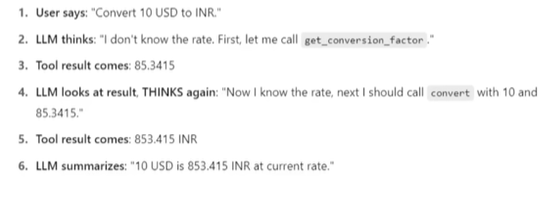

In [ ]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=[get_conversion_factor, convert],
    system_prompt="You are a helpful assistant"
)

response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is the conversion factor between INR and USD, and based on that can you convert 10 inr to usd"}
    ]
})

final_message = response["messages"][-1].content

print(final_message)

**Conversion factor (INR → USD):** 1 INR = **0.01065 USD** (as of the latest update).

**10 INR in USD:**

\[
10 \text{ INR} \times 0.01065 \frac{\text{USD}}{\text{INR}} = 0.1065 \text{ USD}
\]

So, 10 INR is approximately **$0.11 USD** (rounded to two decimal places).
